In [1]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, sample_forward_process_minusx_plus_sqrt2D_dw
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, get_best_params
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [0.5, 0.0],   # mean of first Gaussian
    [-0.5, 0.0],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])

# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal distributions

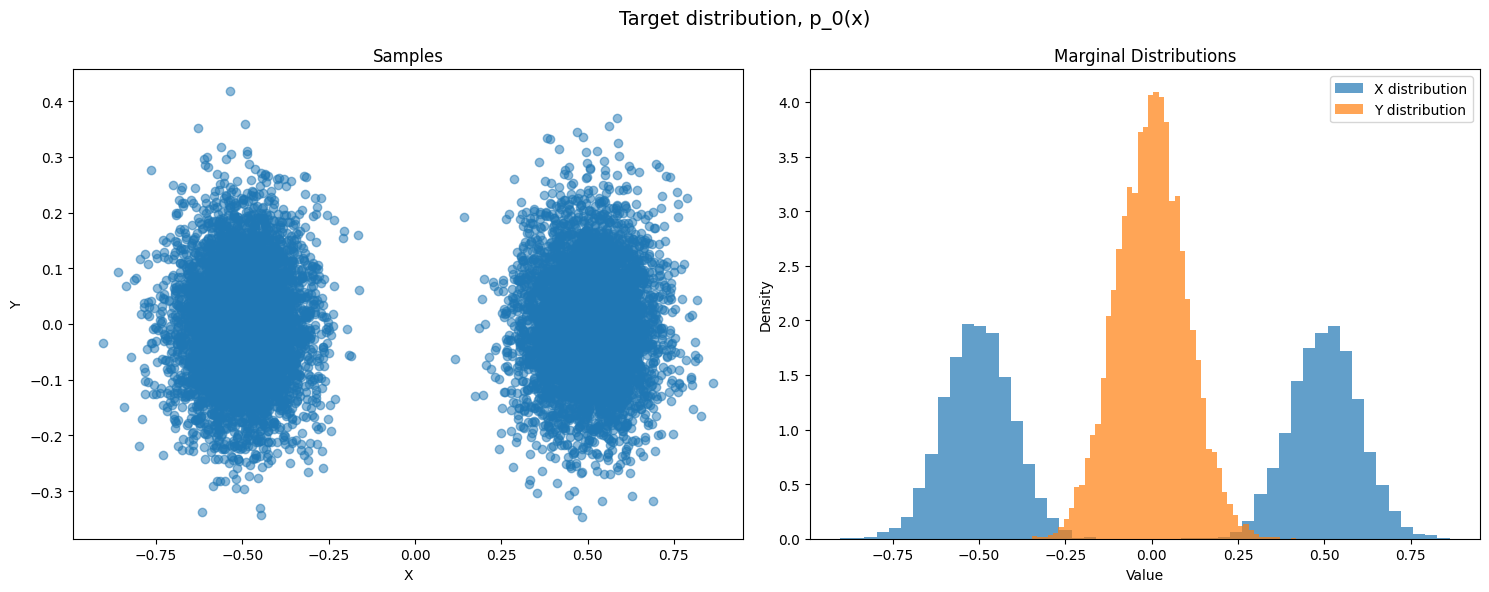

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()


plt.tight_layout()
plt.show()

In [4]:
key, subkey = jr.split(key)
t_forward = .2
samples_t = sample_forward_process_minusx_plus_sqrt2D_dw(t_forward, n_samples, D=1, samples0=samples_0, key=subkey)

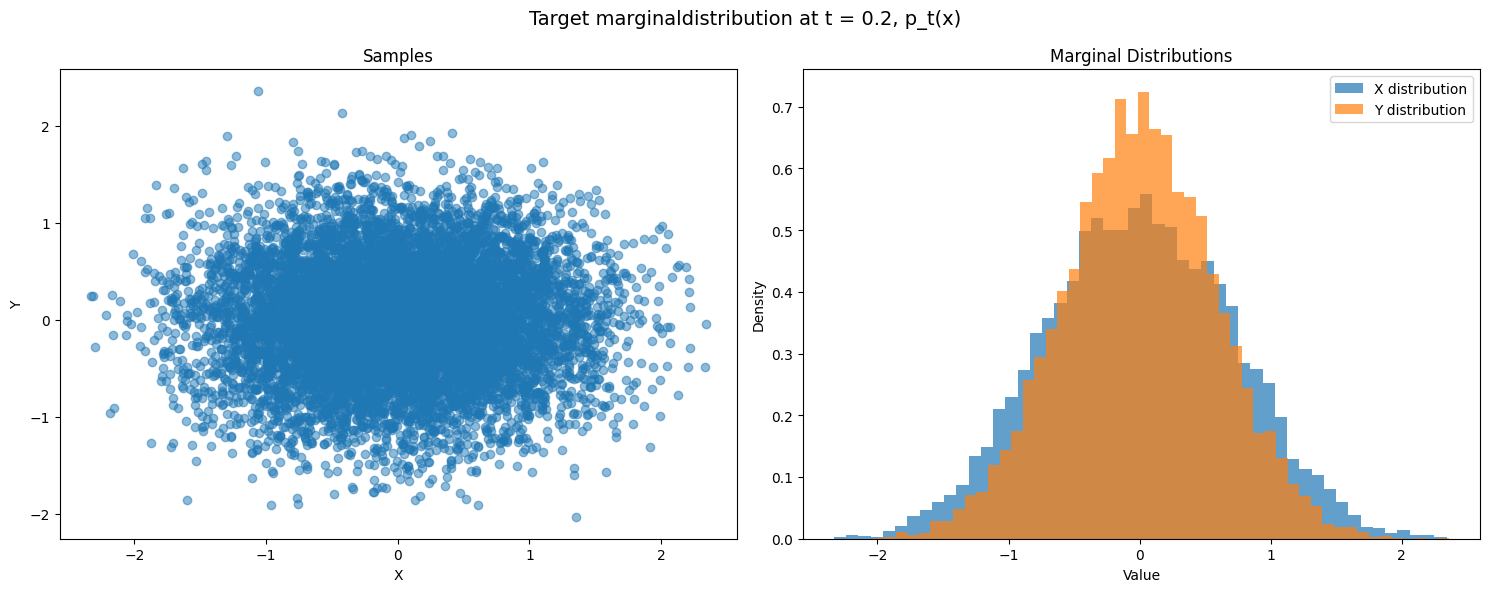

In [5]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Target marginaldistribution at t = {t_forward}, p_t(x)', fontsize=14)


# First subplot: Scatter plot of samples
ax1.scatter(samples_t[:, 0], samples_t[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_t[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_t[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [6]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )

k_b = 1.0
T = .1
def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=k_b, T=T):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [7]:
N_osc = 2

k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 1.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

### Bringe energy into correct form

In [8]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


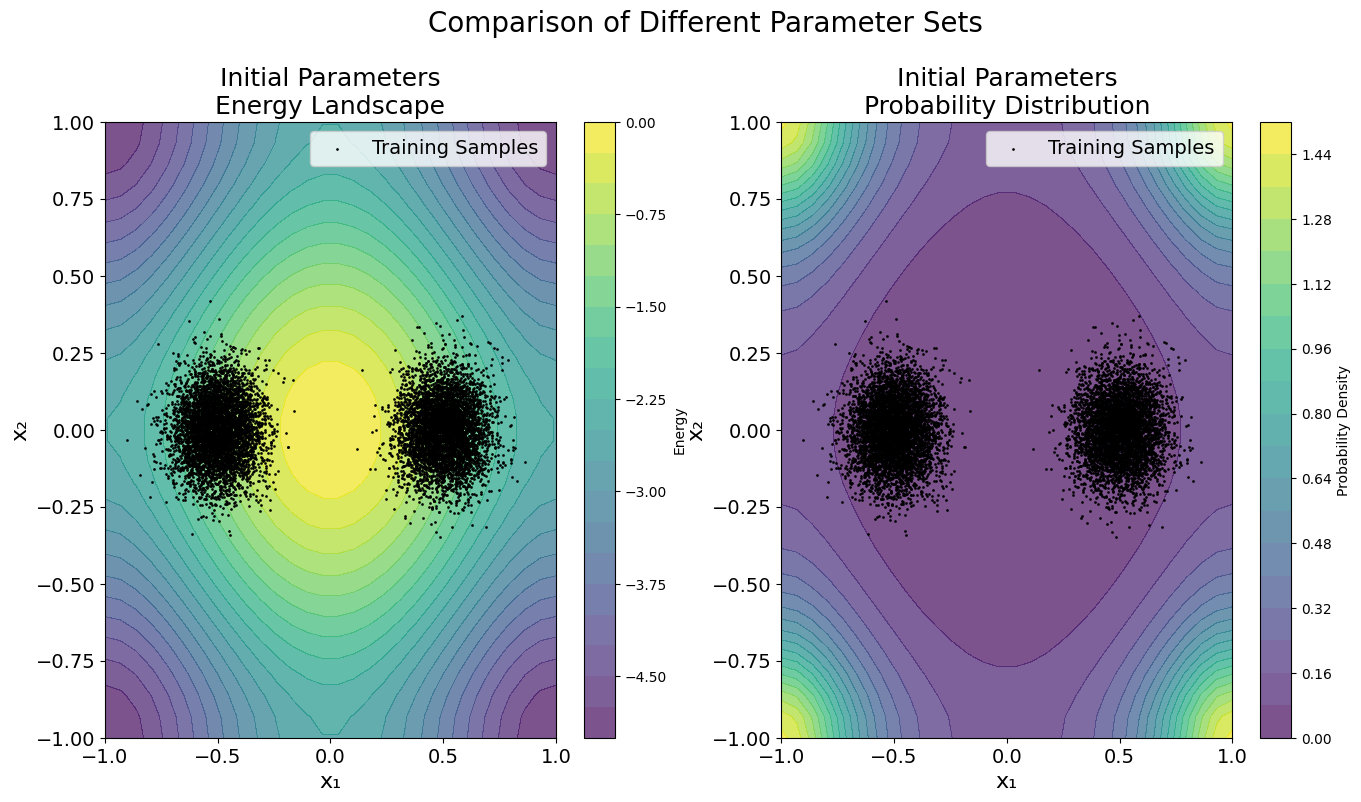

In [9]:
# Example usage:
param_list = [flattened_args_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets" 
)

Optimizing for t = 0.000
Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01  0.01]
Loss: 18.5024
---
Epoch 100
params:
[-0.58563234 -0.01554185  1.75897331  1.97568434  0.20707343  0.00286972]
Loss: -11.4191
---
Epoch 200
params:
[-0.61974391  0.9275315   2.46172393  2.89658171  0.15192115 -0.00337008]
Loss: -23.5117
---
Epoch 300
params:
[-0.79004997  1.81907172  3.18306987  3.7744278   0.12634121  0.03865654]
Loss: -34.6119
---
Epoch 400
params:
[-9.96564152e-01  2.65983996e+00  3.92834085e+00  4.60459263e+00
  1.01491798e-01  2.88146254e-03]
Loss: -44.6015
---
Epoch 500
params:
[-1.20257417  3.45110595  4.68134606  5.39339565  0.10519406  0.04428085]
Loss: -51.9182
---
Epoch 600
params:
[-1.42226329  4.18559121  5.42376898  6.13502272  0.08742353  0.04525367]
Loss: -57.0493
---
Epoch 700
params:
[-1.61304817  4.8714835   6.18284703  6.81266781  0.06563228 -0.03296388]
Loss: -64.9228
---
Epoch 800
params:
[-1.82910764  5.49997205  6.89753784  7.44464572  0.08414079  0.06775043]
Loss: -72

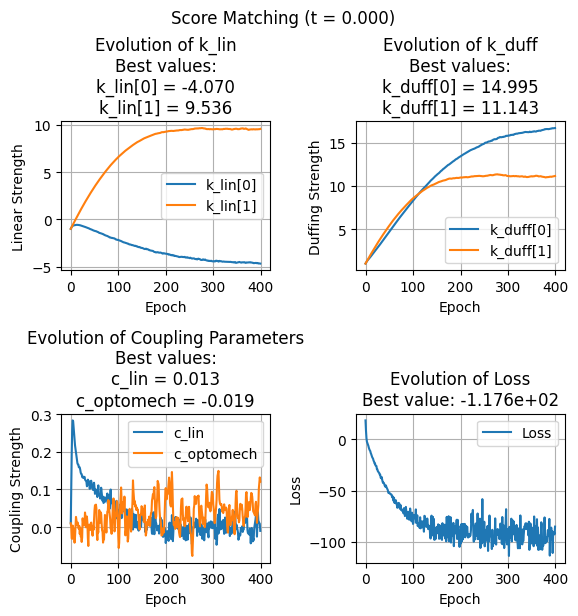

t = 0.000 probability distribution total (should be ≈ 1): 1.000000


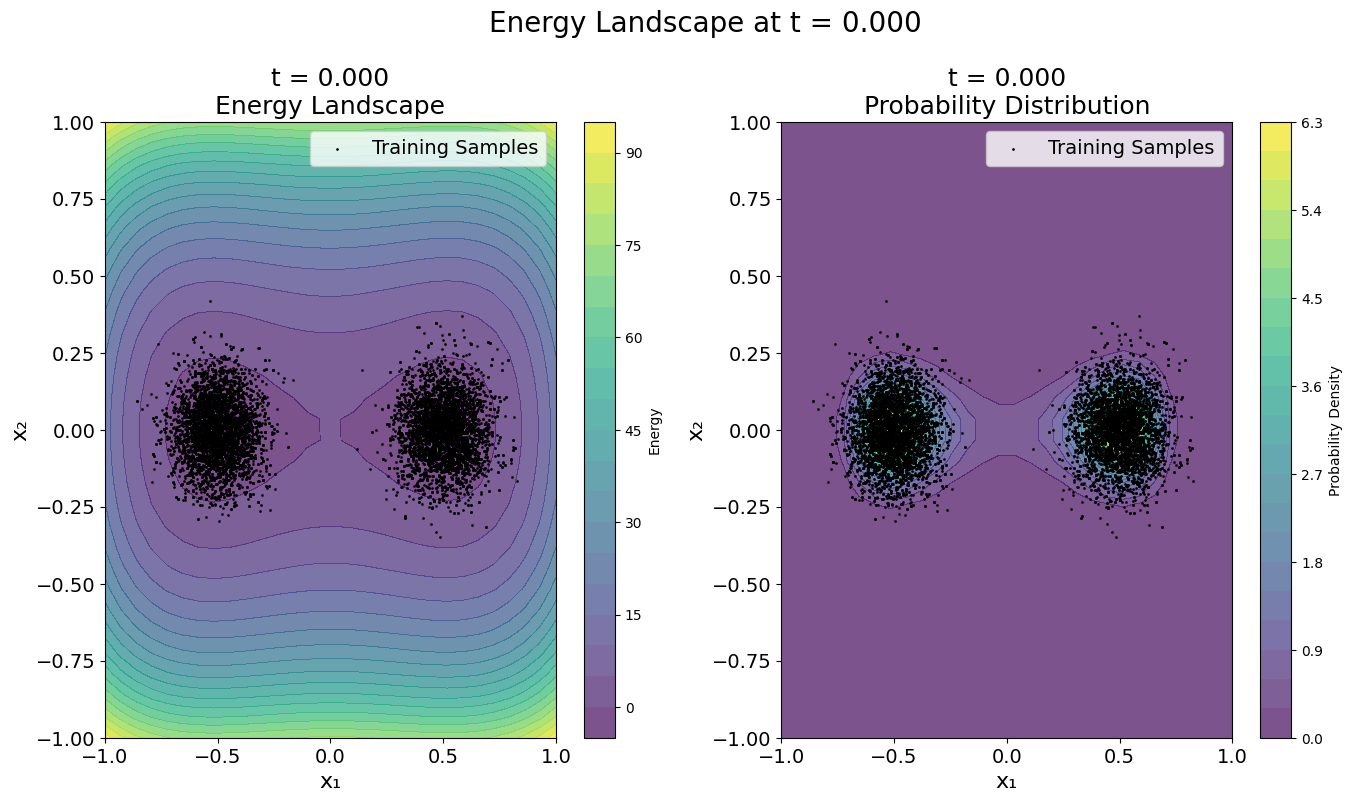

Optimizing for t = 0.022
Epoch 0
params:
[-4.08018888e+00  9.52561456e+00  1.49848719e+01  1.11329175e+01
  2.51266887e-03 -8.88143505e-03]
Loss: 491.4948
---
Epoch 100
params:
[-4.77457118  8.59255311 14.16825946 10.23726713 -0.62977271  0.14265079]
Loss: 240.3618
---
Epoch 200
params:
[-4.97185136  7.71361897 13.569691    9.37770845 -0.56889912  0.13149778]
Loss: 184.2974
---
Epoch 300
params:
[-5.00187804  6.87442873 12.99802195  8.58327479 -0.42231761  0.15265891]
Loss: 221.4039
---
Epoch 400
params:
[-5.00728061  6.08655875 12.38972512  7.82307437 -0.36542705  0.06152894]
Loss: 109.9223
---
Epoch 500
params:
[-4.94336522  5.38254131 11.78126435  7.15915709 -0.25790532  0.0605215 ]
Loss: 154.4742
---
Epoch 600
params:
[-4.82407979  4.73028113 11.18449227  6.50128833 -0.18725665  0.06586063]
Loss: 98.3008
---
Epoch 700
params:
[-4.67932421  4.15075425 10.61764842  5.93752217 -0.13053363  0.01162701]
Loss: 155.4418
---
Epoch 800
params:
[-4.51279195  3.64798497 10.01504372  5.4583568

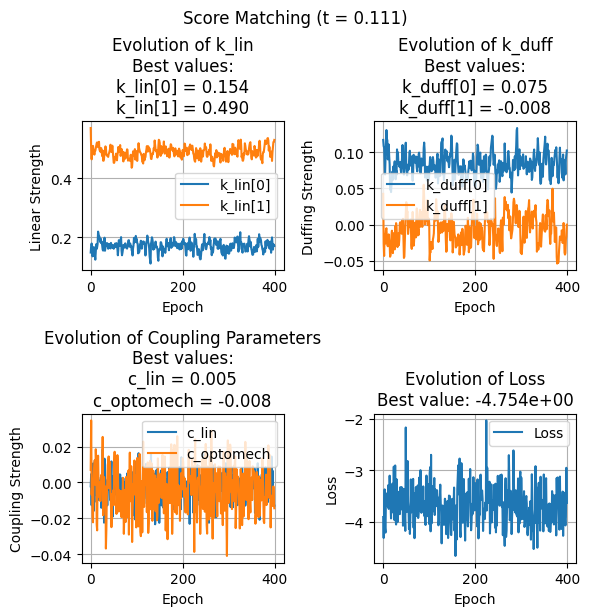

t = 0.111 probability distribution total (should be ≈ 1): 1.000000


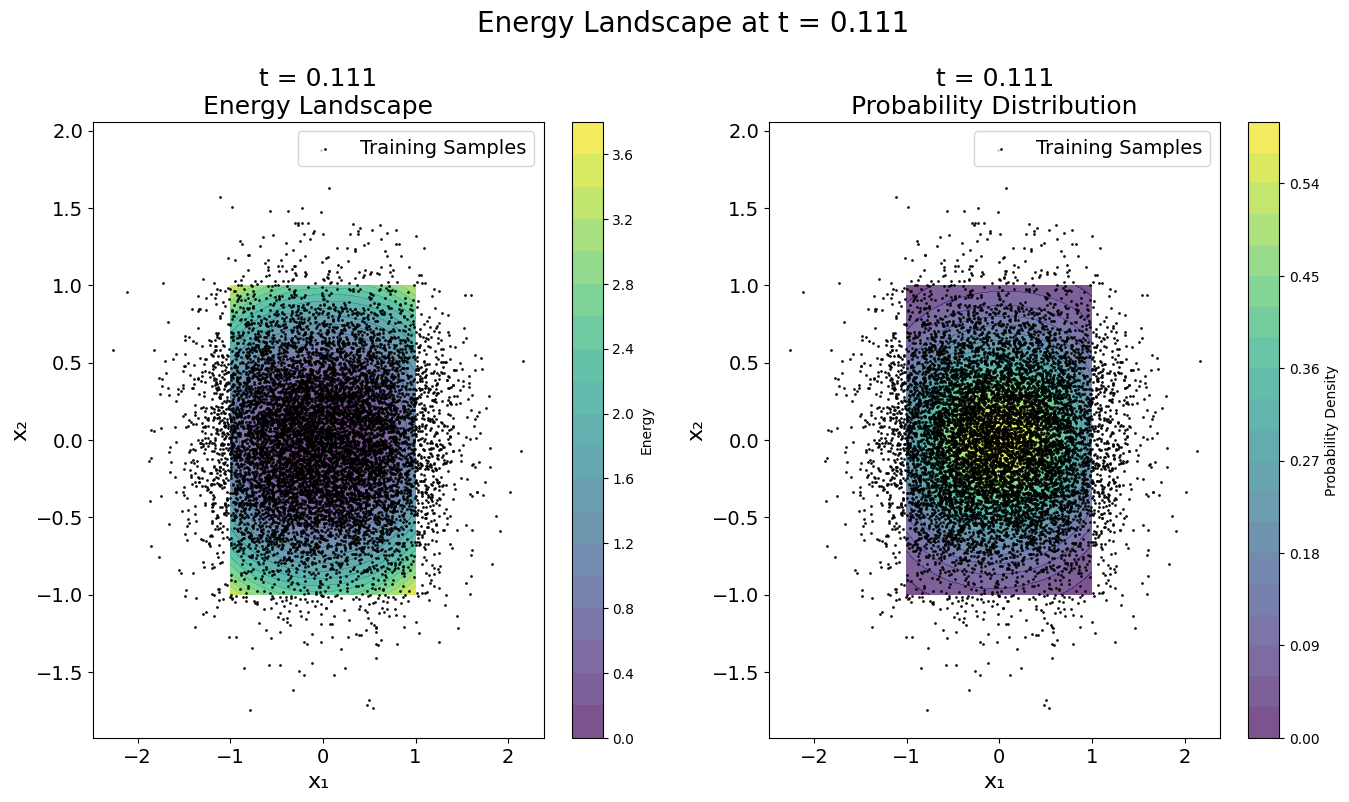

Optimizing for t = 0.133
Epoch 0
params:
[ 0.16360451  0.479566    0.08496654 -0.01799672 -0.00470902  0.00221649]
Loss: -3.2115
---
Epoch 100
params:
[ 0.18643392  0.41822018  0.05247743  0.00642397  0.00575546 -0.00593633]
Loss: -3.5266
---
Epoch 200
params:
[ 0.19511842  0.43781952  0.04914064  0.0236277  -0.00730375 -0.0057664 ]
Loss: -3.2072
---
Epoch 300
params:
[0.17739909 0.41370104 0.04993113 0.00619764 0.00795454 0.00460426]
Loss: -3.5636
---
Epoch 400
params:
[ 0.16962914  0.41664039  0.03811512 -0.02045268 -0.01086732 -0.00726187]
Loss: -3.2935
---
Epoch 500
params:
[ 0.17207982  0.39650541  0.0605618  -0.00749348 -0.00363508 -0.01038933]
Loss: -3.3832
---
Epoch 600
params:
[ 0.20602741  0.44467253  0.04175387 -0.03870624 -0.00258766  0.0223201 ]
Loss: -2.6794
---
Epoch 700
params:
[ 0.16941384  0.40437557  0.04862618 -0.01166532 -0.00175896  0.00166181]
Loss: -2.9792
---
Epoch 800
params:
[ 1.72669832e-01  4.38802403e-01  6.42763003e-02 -3.25791995e-02
  8.16409646e-03 -4.

In [10]:
# Choose loss function and gradient function
loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
gradient_fn_per_batch = None
maximize = False

# Setup optimization parameters
n_time_steps = 10
forward_time_pts = jnp.linspace(0., .2, n_time_steps)
learning_rate = 0.01
n_epochs = 4000
batch_size = 128

# Plotting parameters
plot_steps = True  # Flag to control whether to plot during optimization
plot_slice = 5     # Plot every nth step


# Initialize storage for parameters at each time step
params_history_all_t = []
current_params = flattened_args_initial

# Loop over time points
for t_idx, t_forward in enumerate(forward_time_pts):
    print(f"Optimizing for t = {t_forward:.3f}")
    
    # Generate samples at current time
    key, subkey = jr.split(key)
    samples_t = sample_forward_process_minusx_plus_sqrt2D_dw(
        t_forward, n_samples, D=1, samples0=samples_0, key=subkey
    )
    
    # Perform optimization starting from previous best parameters
    key, subkey = jr.split(key)
    
    params_history, loss_history = run_optimization(
        loss_fn_per_batch=loss_fn_per_batch,
        params_initial=current_params,
        samples=samples_t,
        gradient_fn_per_batch=gradient_fn_per_batch,
        key=subkey,
        batch_size=batch_size,
        learning_rate=learning_rate,
        n_epochs=n_epochs,
        maximize=maximize
    )
    
    _, best_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
    k_lin_best, k_duff_best, c_lin_best, c_optomech_best = unflatten(best_params)
    current_params, _ = flatten_util.ravel_pytree(best_params)
    params_history_all_t.append(current_params)
    
    if plot_steps and t_idx % plot_slice == 0:
        # Plot optimization progress
        plot_parameter_evolution(
            params_history=params_history,
            loss_history=loss_history,
            unflatten=unflatten,
            N_osc=N_osc,
            slicing=10,
            title=f"Score Matching (t = {t_forward:.3f})",
            maximize=maximize
        )
        # Plot current energy landscape
        plot_energy_and_distributions(
            energy_fn=energy_fn,
            param_list=[current_params],
            samples=samples_t,
            x1_range=(-1, 1),
            x2_range=(-1, 1),
            n_points=30,
            titles=[f"t = {t_forward:.3f}"],
            fontsize=16,
            sample_stride=1,
            suptitle=f"Energy Landscape at t = {t_forward:.3f}"
        )
    
# Convert params_history_all_t to array for easier analysis
params_history_all_t = jnp.array(params_history_all_t)


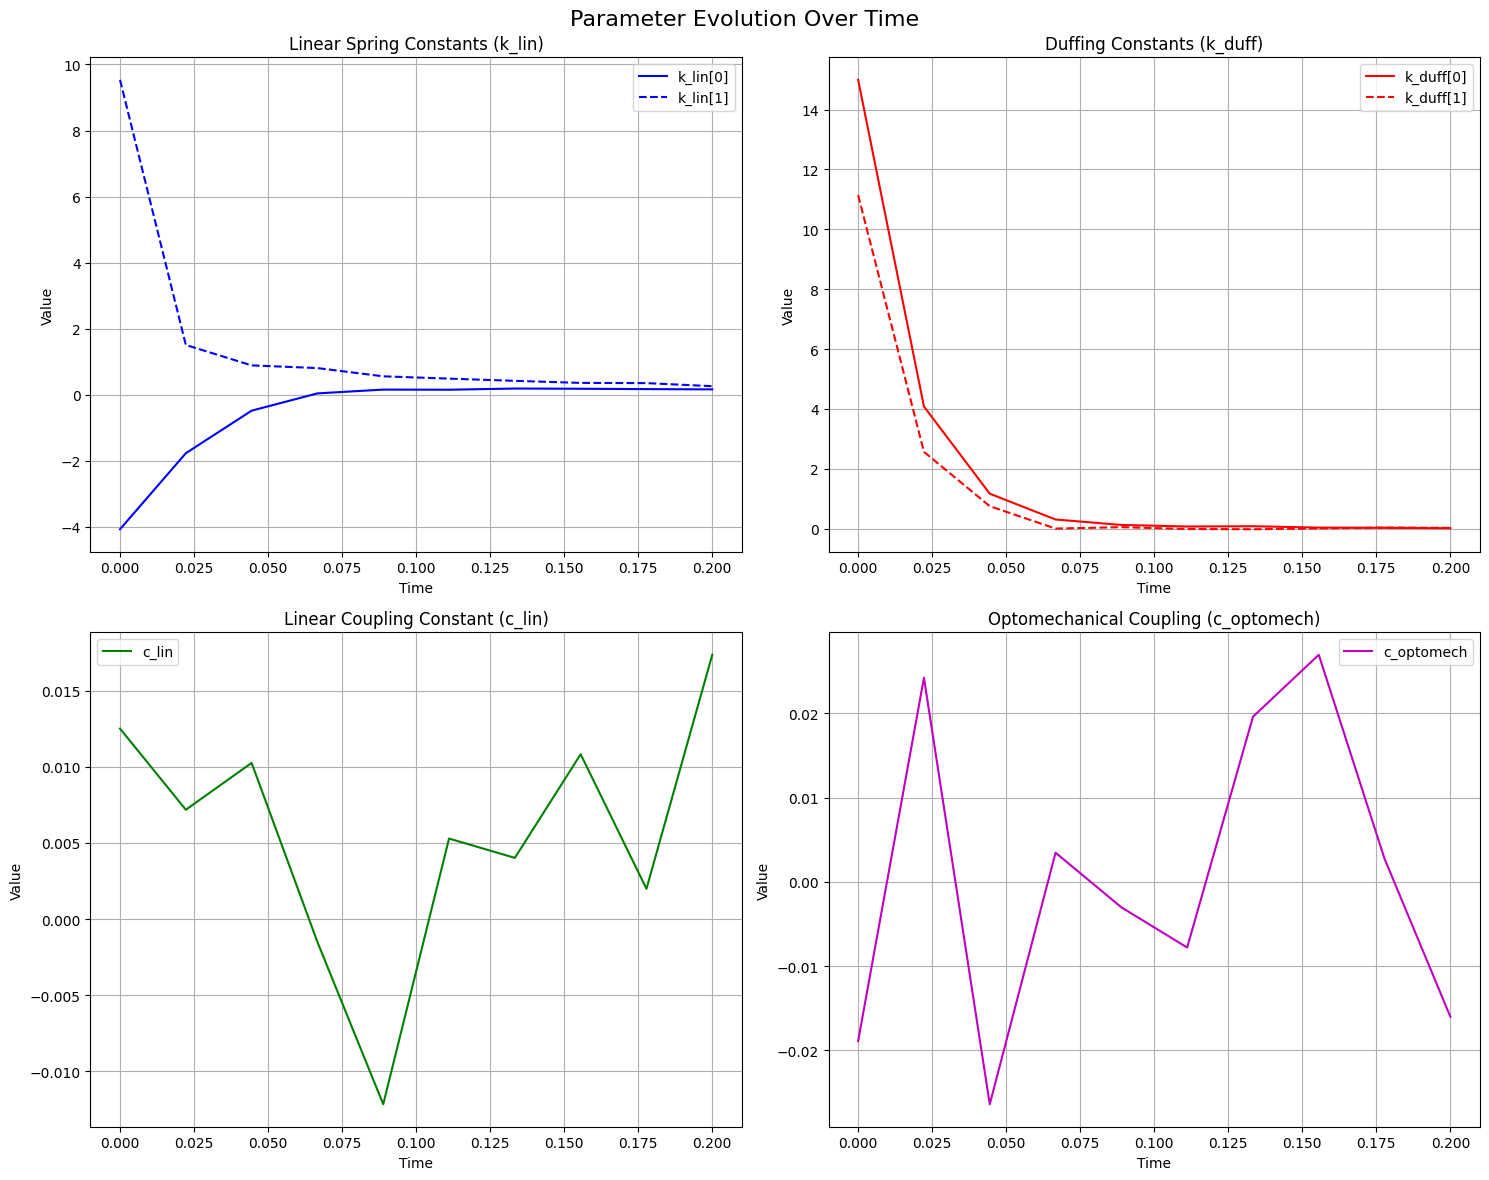

In [11]:
# Create a figure with subplots for each parameter type
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time', fontsize=16)

# Time points
time_points = forward_time_pts

# Plot k_lin parameters
ax1.plot(time_points, params_history_all_t[:, 0], 'b-', label='k_lin[0]')
ax1.plot(time_points, params_history_all_t[:, 1], 'b--', label='k_lin[1]')
ax1.set_title('Linear Spring Constants (k_lin)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.legend()
ax1.grid(True)

# Plot k_duff parameters
ax2.plot(time_points, params_history_all_t[:, 2], 'r-', label='k_duff[0]')
ax2.plot(time_points, params_history_all_t[:, 3], 'r--', label='k_duff[1]')
ax2.set_title('Duffing Constants (k_duff)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Value')
ax2.legend()
ax2.grid(True)

# Plot c_lin parameter
ax3.plot(time_points, params_history_all_t[:, 4], 'g-', label='c_lin')
ax3.set_title('Linear Coupling Constant (c_lin)')
ax3.set_xlabel('Time')
ax3.set_ylabel('Value')
ax3.legend()
ax3.grid(True)

# Plot c_optomech parameter
ax4.plot(time_points, params_history_all_t[:, 5], 'm-', label='c_optomech')
ax4.set_title('Optomechanical Coupling (c_optomech)')
ax4.set_xlabel('Time')
ax4.set_ylabel('Value')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

### Contrastive Divergence 1

In [ ]:
# Define optimization parameters
learning_rate = learning_rate
n_epochs = n_epochs
batch_size = batch_size
loss_fn_per_batch_SM = setup_score_matching_loss_per_batch(energy_fn)
key, subkey = jr.split(key)
cd1_grad = lambda params, batch: -CD1_gradient(energy_fn, 
                                               batch, 
                                               params, 
                                               dt=0.001, 
                                               D=1, 
                                               key=key, 
                                               num_noise_samples=100)

params_history_cd1, loss_history_cd1 = run_optimization(loss_fn_per_batch = loss_fn_per_batch_SM, 
                                                        params_initial = flattened_args_initial, 
                                                        samples=samples, 
                                                        gradient_fn_per_batch = cd1_grad, 
                                                        key=subkey,
                                                        batch_size=batch_size, 
                                                        learning_rate=learning_rate, 
                                                        n_epochs=n_epochs)

In [ ]:
k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1 = plot_parameter_evolution(
    params_history=params_history_cd1,
    loss_history=loss_history_cd1,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=10,
    title="CD1"
)
args_best_cd1 = (k_lin_best_cd1, k_duff_best_cd1, c_lin_best_cd1, c_optomech_best_cd1)
flattened_args_best_cd1, _ = flatten_util.ravel_pytree(args_best_cd1)


### MLE

In [ ]:
# Define optimization parameters
learning_rate = .5
n_epochs = 100
batch_size = samples.shape[0]//2
key, subkey = jr.split(key)
loss_fn_per_batch_MLE = setup_MLE_loss_per_batch(energy_fn)
gradient_fn_per_batch_MLE = setup_MLE_gradient_per_batch(energy_fn, 
                                                     N_osc, 
                                                     gamma=1.0, 
                                                     k_b=1.0, 
                                                     T=1.0, 
                                                     t0=0.0, 
                                                     t1=10.0, 
                                                     N_samples=1000, 
                                                     dt0=0.01, 
                                                     initial_state=jnp.array([0.,0.]))

params_history_mle, loss_history_mle = run_optimization(loss_fn_per_batch = loss_fn_per_batch_MLE, 
                                                        params_initial = flattened_args_initial, 
                                                        samples=samples,
                                                        gradient_fn_per_batch = gradient_fn_per_batch_MLE, 
                                                        key=key,
                                                        batch_size=batch_size, 
                                                        learning_rate=learning_rate, 
                                                        n_epochs=n_epochs, 
                                                        maximize=True)

In [ ]:
k_lin_best_mle, k_duff_best_mle, c_lin_best_mle, c_optomech_best_mle = plot_parameter_evolution(
    params_history=params_history_mle,
    loss_history=loss_history_mle,
    unflatten=unflatten,
    N_osc=N_osc,
    slicing=1,
    title="MLE",
    maximize=True
)
args_best_mle = (k_lin_best_mle, k_duff_best_mle, c_lin_best_mle, c_optomech_best_mle)
flattened_args_best_mle, _ = flatten_util.ravel_pytree(args_best_mle)

### Compare solutions

In [ ]:
# Example usage:
param_list = [flattened_args_initial, flattened_args_best_sm, flattened_args_best_cd1, flattened_args_best_mle]
titles = ["Initial Parameters", "Score Matching Best", "CD-1 Best", "MLE Best"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples,
    x1_range=(-1, 1),    
    x2_range=(-1, 1),    
    n_points=30,        
    titles=titles,       
    figsize=None,    
    fontsize=16,
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets"  
)

### Run the SDE on one of the optimized energy landscape

In [25]:
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, flattened_args_best_sm, N_osc)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 10000)
dt0 = ts[1] - ts[0]
initial_state    = jnp.array([0.,0.])

solution = solve_SDE(drift_fn, diffusion_fn, initial_state, t0, t1, ts.shape[0], dt0)
sde_samples = solution.ys

In [ ]:
# Example usage:
param_list = [flattened_args_best_sm]
titles = ["Score Matching Best Energy "]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples,
    sample_stride=1,
    x1_range=(-1, 1),    # optional
    x2_range=(-1, 1),    # optional
    n_points=30,        # optional
    titles=titles,       # optional
    figsize=None,    # optional
    fontsize=12,         # optional
    suptitle="Energy landscape with SDE samples"  # optional
)